## PLOT RESULTS

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

In [ ]:
from synco import run_pipeline, build_pipeline_config

In [14]:
from pathlib import Path

CFG = {
    "paths": {
        "base": Path("data/DrugLogics"),
        "pipeline_runs": Path("data/DrugLogics/20250804/drabme_out"),
        "input": Path("data/input"),
        "output": None
    },
    "general": {
        "cell_lines": ['SNU81', 'CAR1', 'HT115', 'LS123', 'NCIH508', 'NCIH747', 'NCIH716', 'T84', 'SW1417', 'SW948', 'SW837', 'SW1463', 'SW1116', 'SW620', 'CL11', 'C2BBE1'],
        "run_date": "20250804",
        "verbose": True,
    },
    "compare": {
        "prediction_method": "DrugLogics",
        "threshold": 0.001,
        "synergy_column": "synergy",
        "analysis_mode": "inhibitor_combination"
    }
    # ADVANCE SETTINGS
    # "advanced": {    }
}


In [15]:
# Build pipeline configuration
pipeline_config = build_pipeline_config(CFG)

# Pipeline execution
synco_results = run_pipeline(pipeline_config)

=== COMPARISON SUMMARY ===

Items in experimental data: 11
Items in predicted data: 11
Common items to compare: 11
Skipped from experimental: 0
Skipped from predicted: 0

=== GLOBAL RESULTS ===

Total comparisons: 176
Global matches: 127 (72.16%)
Global mismatches: 49 (27.84%)
Global True Positives: 103
Global True Negatives: 24
Global False Positives: 33
Global False Negatives: 16
Global Accuracy: 72.16%
Global Recall: 86.55%
Global Precision: 75.74%


In [5]:
cell_metrics = synco_results['synergy_comparison']
cell_metrics

,True Positive,True Negative,False Positive,False Negative,Total,Match,Mismatch,Match %,Mismatch %,Accuracy,Recall,Precision
NCIH716,7,2,1,1,11,9,2,81.818182,18.181818,81.82,87.50,87.50
NCIH508,9,1,1,0,11,10,1,90.909091,9.090909,90.91,100.00,90.00
SW948,9,2,0,0,11,11,0,100.000000,0.000000,100.00,100.00,100.00
CAR1,9,0,1,1,11,9,2,81.818182,18.181818,81.82,90.00,90.00
T84,8,0,0,3,11,8,3,72.727273,27.272727,72.73,72.73,100.00
SNU81,7,0,2,2,11,7,4,63.636364,36.363636,63.64,77.78,77.78
CL11,3,2,5,1,11,5,6,45.454545,54.545455,45.45,75.00,37.50
SW1463,5,2,4,0,11,7,4,63.636364,36.363636,63.64,100.00,55.56
SW837,4,2,2,3,11,6,5,54.545455,45.454545,54.55,57.14,66.67
HT115,5,1,5,0,11,6,5,54.545455,45.454545,54.55,100.00,50.00


In [7]:
roc_metrics = synco_results['roc_results']
traces_roc, traces_pr, rocauc_score_list, prauc_score_list, metrics_df = roc_metrics
metrics_df

,cell_line,roc_auc,pr_auc,f1_score,threshold_used,n_positive,n_negative,pred_min,pred_max
0,CAR1,0.867816,0.985376,0.950820,0.001,29.0,3.0,-0.624607,0.0
1,LS123,0.703704,0.941948,0.915254,0.001,27.0,5.0,-1.435914,0.0
2,T84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NCIH508,0.910714,0.985969,0.933333,0.001,28.0,4.0,-1.169443,0.0
4,NCIH716,0.825521,0.919568,0.857143,0.001,24.0,8.0,-0.735926,0.0
5,NCIH747,0.736979,0.901042,0.857143,0.001,24.0,8.0,-0.357622,0.0
6,SNU81,0.531250,0.798733,0.857143,0.001,24.0,8.0,-0.626208,0.0
7,SW620,0.646484,0.571008,0.666667,0.001,16.0,16.0,-0.468207,0.0
8,SW837,0.586364,0.739268,0.814815,0.001,22.0,10.0,-0.230450,0.0
9,SW948,0.907051,0.970499,0.896552,0.001,26.0,6.0,-1.174535,0.0


In [16]:
combi_metrics = synco_results['synergy_comparison']
combi_metrics

,True Positive,True Negative,False Positive,False Negative,Total,Match,Mismatch,Match %,Mismatch %,Accuracy,Recall,Precision
CHK1_inhibitors + MK2_inhibitors,5,1,9,1,16,6,10,37.50,62.50,37.50,83.33,35.71
CyclinD_inhibitors + mTOR_inhibitors,7,0,9,0,16,7,9,43.75,56.25,43.75,100.00,43.75
BCL2L1_inhibitors + mTOR_inhibitors,13,0,3,0,16,13,3,81.25,18.75,81.25,100.00,81.25
CHK1_inhibitors + CyclinD_inhibitors,2,7,7,0,16,9,7,56.25,43.75,56.25,100.00,22.22
AKT_inhibitors + EGFR_inhibitors,13,0,2,1,16,13,3,81.25,18.75,81.25,92.86,86.67
ERK_inhibitors + mTOR_inhibitors,16,0,0,0,16,16,0,100.00,0.00,100.00,100.00,100.00
CHK1_inhibitors + Wee1_inhibitors,7,3,1,5,16,10,6,62.50,37.50,62.50,58.33,87.50
CHK1_inhibitors + PARP_inhibitors,0,11,0,5,16,11,5,68.75,31.25,68.75,0.00,0.00
AKT_inhibitors + mTOR_inhibitors,13,0,2,1,16,13,3,81.25,18.75,81.25,92.86,86.67
EGFR_inhibitors + mTOR_inhibitors,11,2,0,3,16,13,3,81.25,18.75,81.25,78.57,100.00


### RING PLOTS

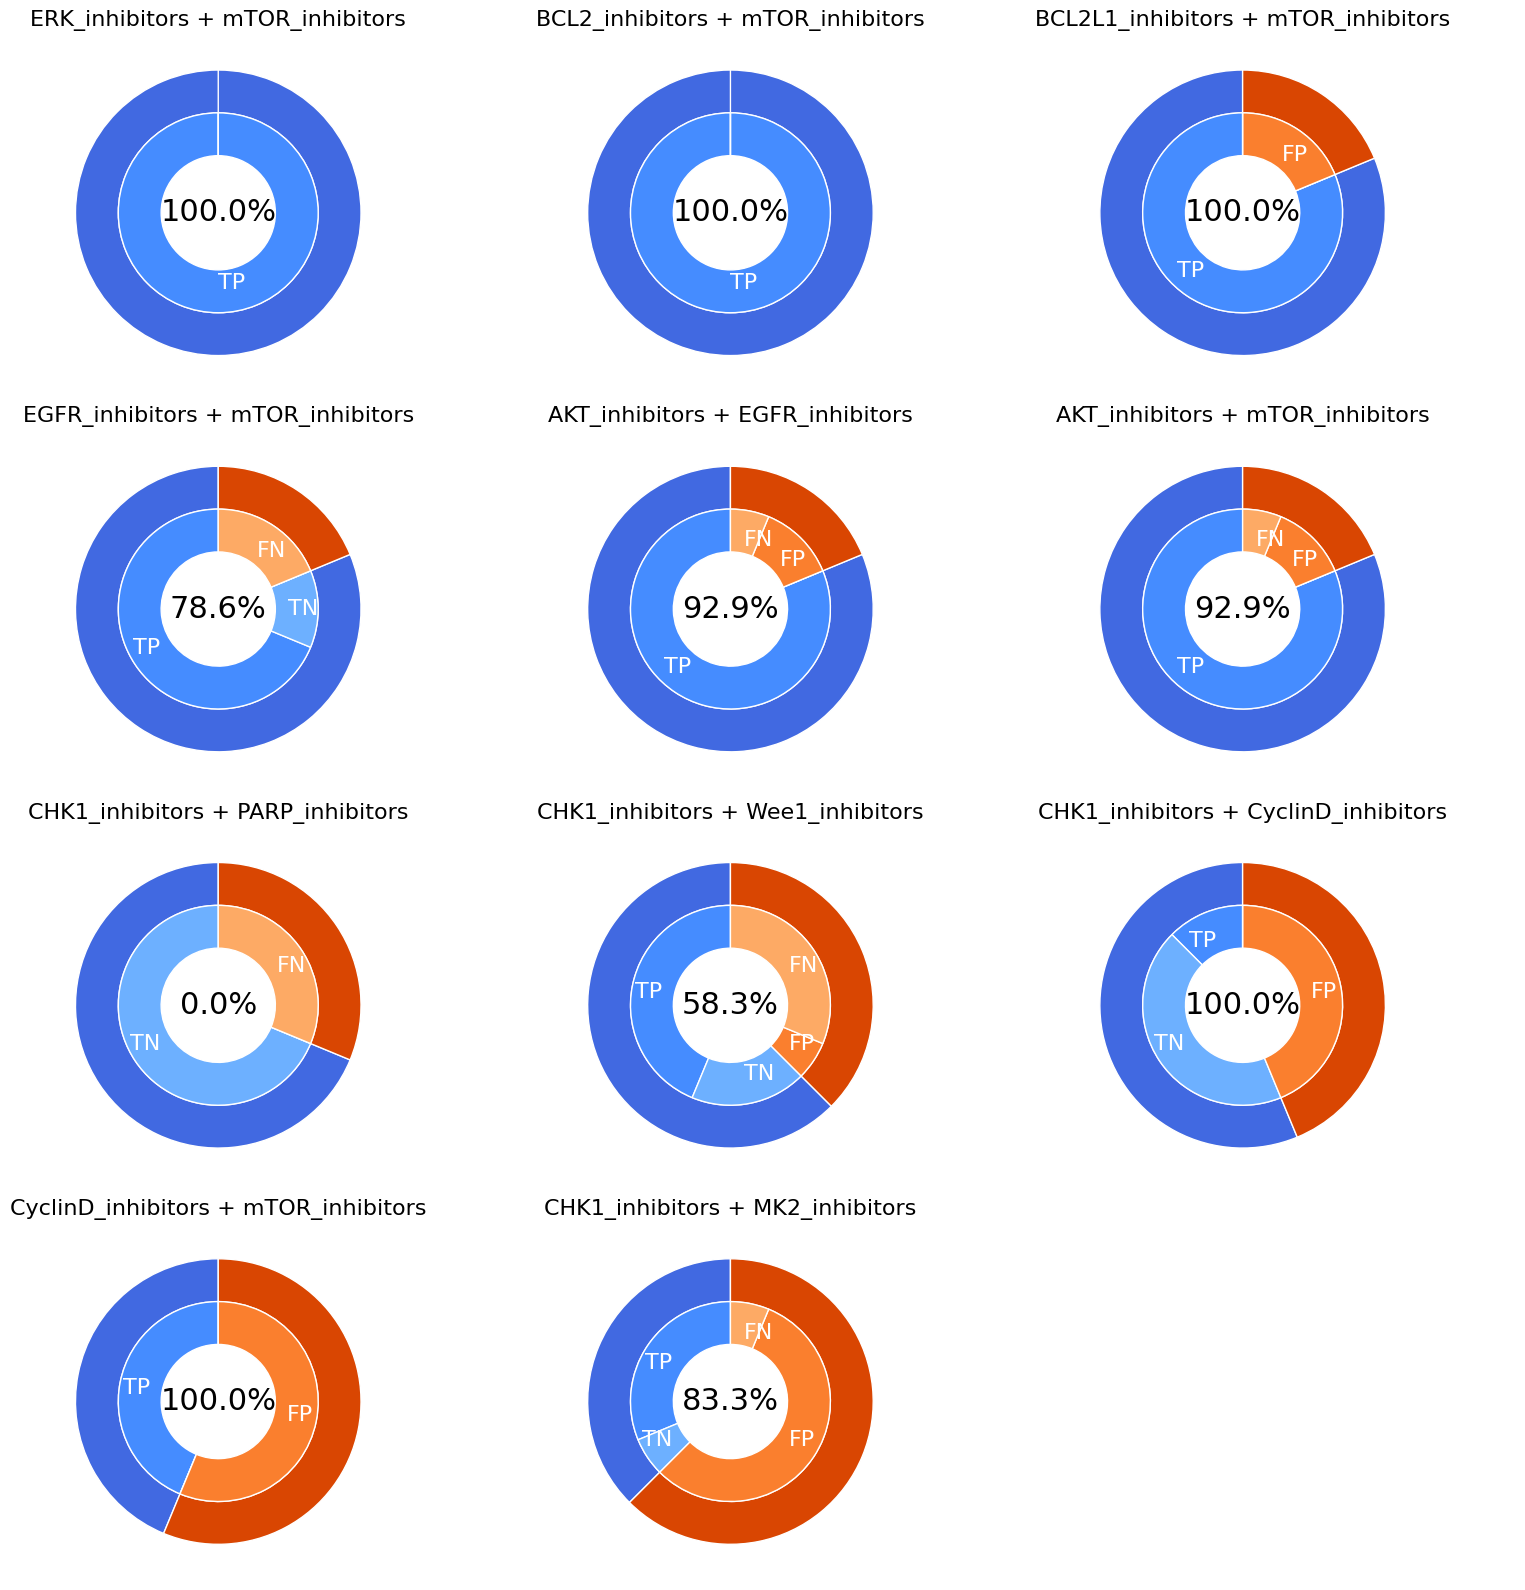

In [17]:
# RING PLOT BY DRUG COMBINATION /////////////////////////////////////////////

def plot_combination_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=22)

    # Title
    ax.set_title(f"{row.name}", fontsize=16)

# Plot all target combinations in a grid
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

# Sort combi_match_df by Recall
combi_match_df = combi_metrics.sort_values(by='Accuracy', ascending=False)

for ax, (_, row) in zip(axes, combi_match_df.iterrows()):
    plot_combination_rings(ax, row)

# Hide any unused subplots
for ax in axes[len(combi_match_df):]:
    ax.axis('off')

# Add legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
]

# Top right outside the plot
# fig.legend(handles=legend_elements, fontsize=14, loc='lowe right', bbox_to_anchor=(1.1, 0.9))

plt.tight_layout()
# plt.savefig(f"{plots_path}rings_combination.png", bbox_inches='tight')
plt.show()

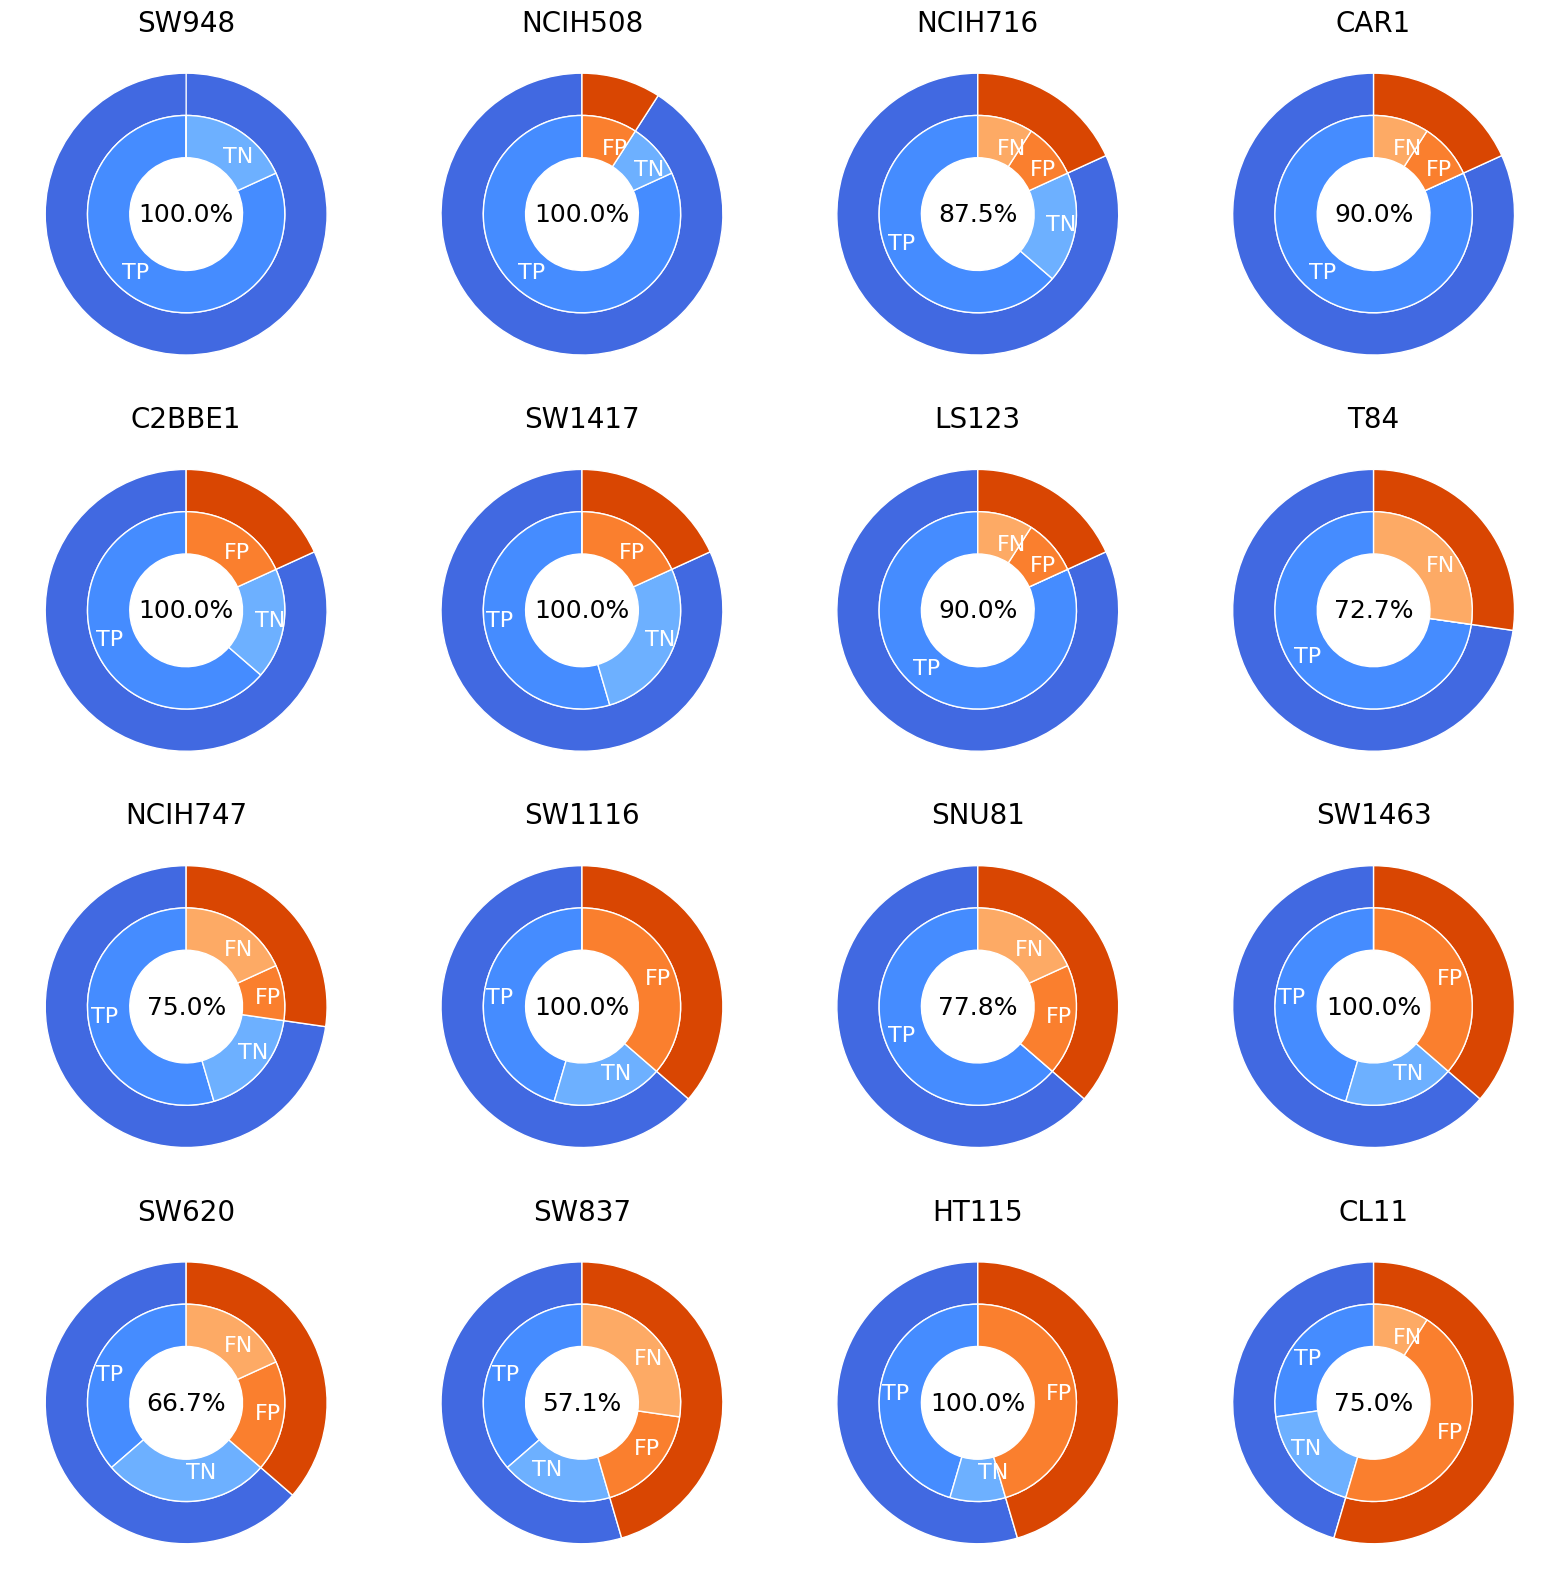

In [9]:
# RING PLOT BY CELL LINE /////////////////////////////////////////////

# cell_line_match_df.columns
def plot_cell_line_rings(ax, row):
    ax.set_aspect('equal')

    # Outer ring (Match / Mismatch)
    outer_values = [row['Match'], row['Mismatch']]
    outer_colors = ["royalblue", "#D94602"]

    ax.pie(
        outer_values,
        radius=1,
        startangle=90,
        colors=outer_colors,
        # labels=['Match', 'Mismatch'],
        wedgeprops=dict(width=0.3, edgecolor='w'),
        textprops={'fontsize': 14}
    )

    # Inner ring (TP / TN / FP / FN)
    inner_values = [row['True Positive'], row['True Negative'], row['False Positive'], row['False Negative']]
    inner_values = [int(value) for value in inner_values]
    inner_colors = ["#458cff", "#6db0ff", "#FA7F2E", "#FDAA65"]

    # Add labels for the inner ring if there are more than 0 values
    labels = ['TP', 'TN', 'FP', 'FN']
    for i, value in enumerate(inner_values):
        if value > 0:
            labels[i] = f"{labels[i]}"
        elif value == 0:
            labels[i] = ''

    ax.pie(
        inner_values,
        radius=0.7,
        startangle=90,
        colors=inner_colors,
        labels=labels,
        labeldistance=0.7,
        textprops={'color': 'w', 'fontsize': 16},
        wedgeprops=dict(width=0.3, edgecolor='w')
    )

    # Central text
    ax.text(0, 0, f"{row['Recall']:.1f}%", ha='center', va='center', fontsize=18)

    # Title
    ax.set_title(f"{row.name}", fontsize=20, pad=5)

# Plot all cell lines in a grid
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

# Sort the DataFrame by Recall
cell_line_match_df = cell_metrics.sort_values(by='Accuracy', ascending=False)

for ax, (_, row) in zip(axes, cell_line_match_df.iterrows()):
    plot_cell_line_rings(ax, row)

# Hide any unused subplots
for ax in axes[len(cell_line_match_df):]:
    ax.axis('off')

# # Add legend
# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', label='Correct prediction', markerfacecolor='royalblue', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='Missed prediction', markerfacecolor='#D94602', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='True Positives', markerfacecolor='#458cff', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='True Negatives', markerfacecolor='#6db0ff', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='False Positives', markerfacecolor='#FA7F2E', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='False Negatives', markerfacecolor='#FDAA65', markersize=15),
#     Line2D([0], [0], marker='o', color='w', label='% Recall', markerfacecolor='w', markersize=15),
# ]
# # Top right outside the plot
# fig.legend(handles=legend_elements, fontsize=16, loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
# plt.savefig(f"{plots_path}rings_cell_lines.png", bbox_inches='tight')
plt.show()

### ROC AUC

In [13]:
# Get plot_curves from features.plot_roc_metrics
from synco.features.plot_roc_metrics import plot_curves

# Plot ROC and PR curves
plot_curves(
    traces=traces_roc,
    auc_score_list=rocauc_score_list,
    model="neko_oncologics",
    specific_date="20250804",
    tissue='all',
    metric='ROC',
)
